     TASK 2: UNIFIED EXPLORATORY DATA ANALYSIS (EDA) REPORT        

• Target Output Variable Identified: Y_phys
• Number of Total Input Features:   15
------------------------------------------------------------------



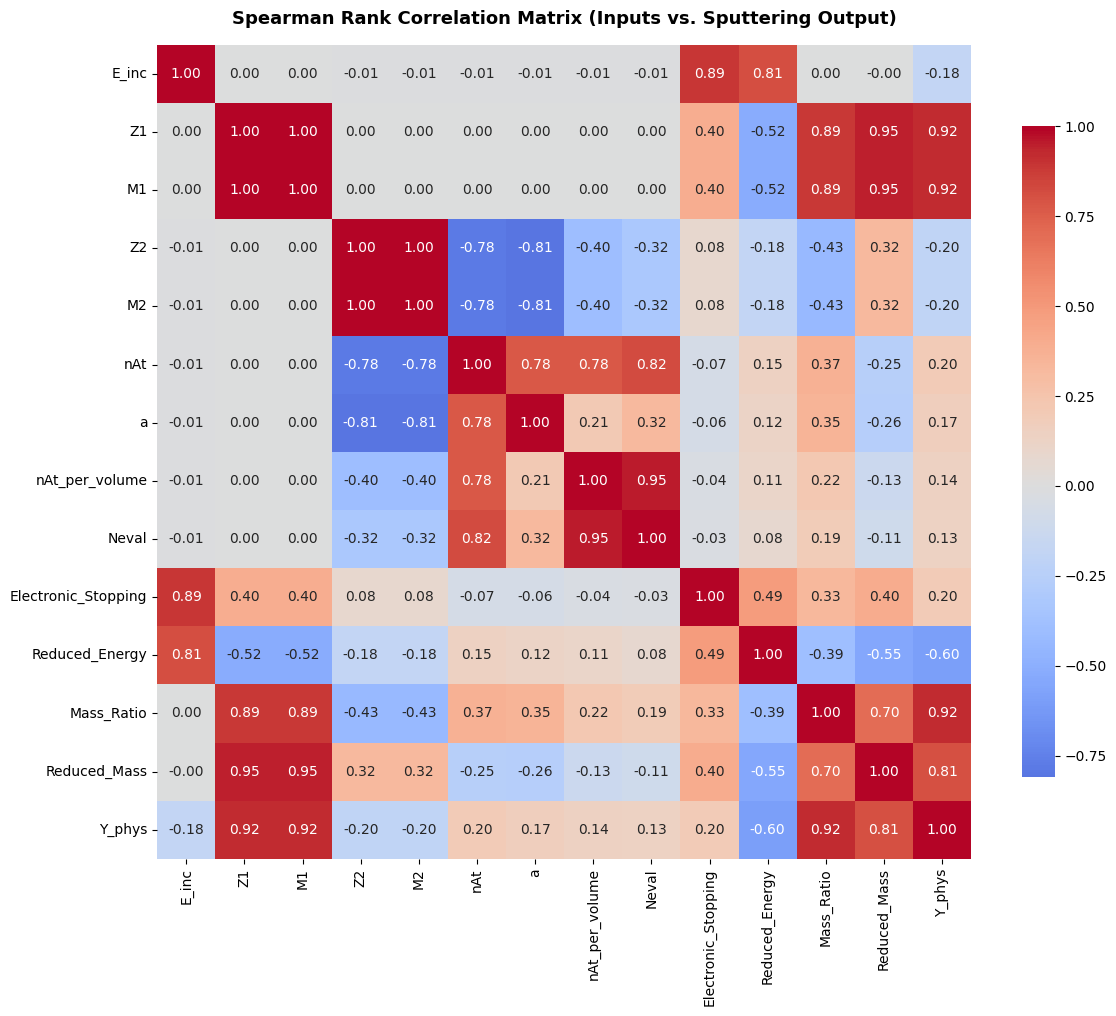

--- Spearman Coefficients Sorted Against Output (Y_phys) ---
Y_phys                 1.000000
Z1                     0.919779
M1                     0.919779
Mass_Ratio             0.917296
Reduced_Mass           0.805094
nAt                    0.199982
Electronic_Stopping    0.198683
a                      0.169129
nAt_per_volume         0.142439
Neval                  0.132632
E_inc                 -0.181603
Z2                    -0.201644
M2                    -0.201644
Reduced_Energy        -0.596344
------------------------------------------------------------------



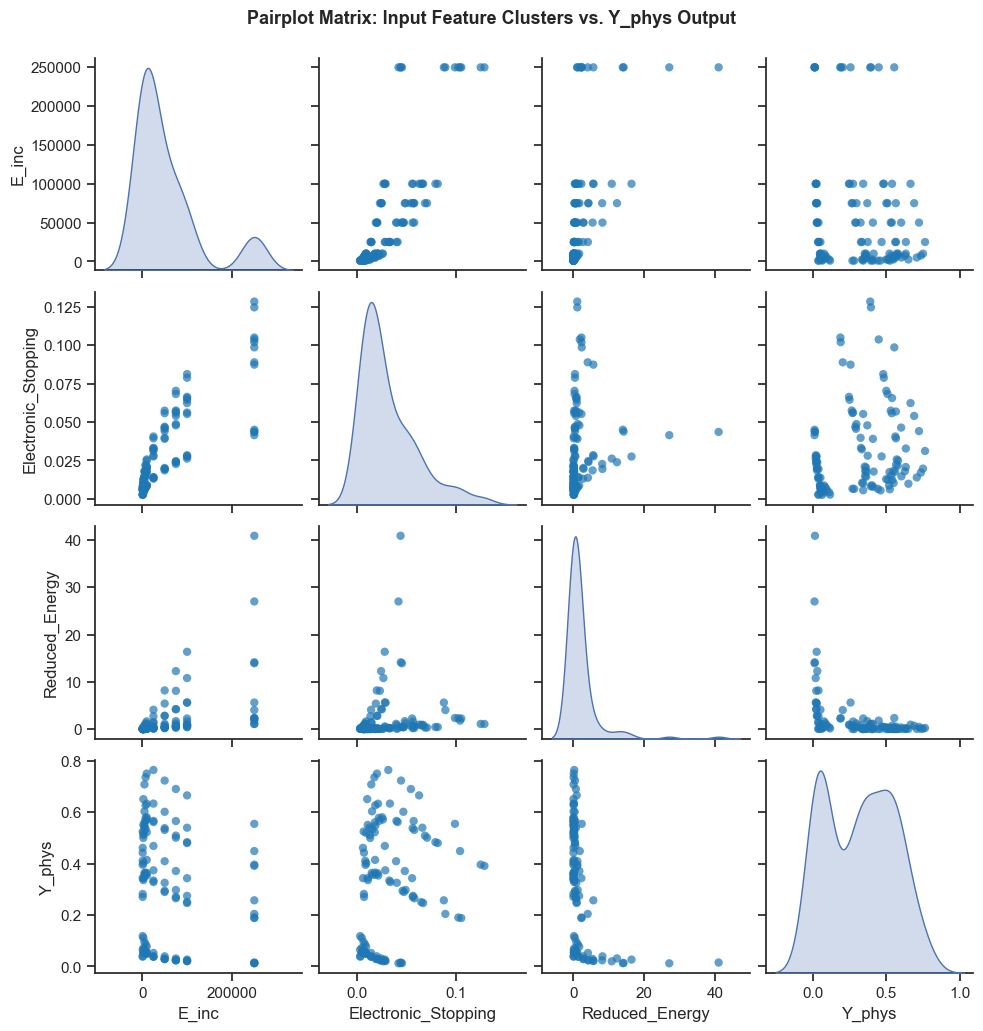

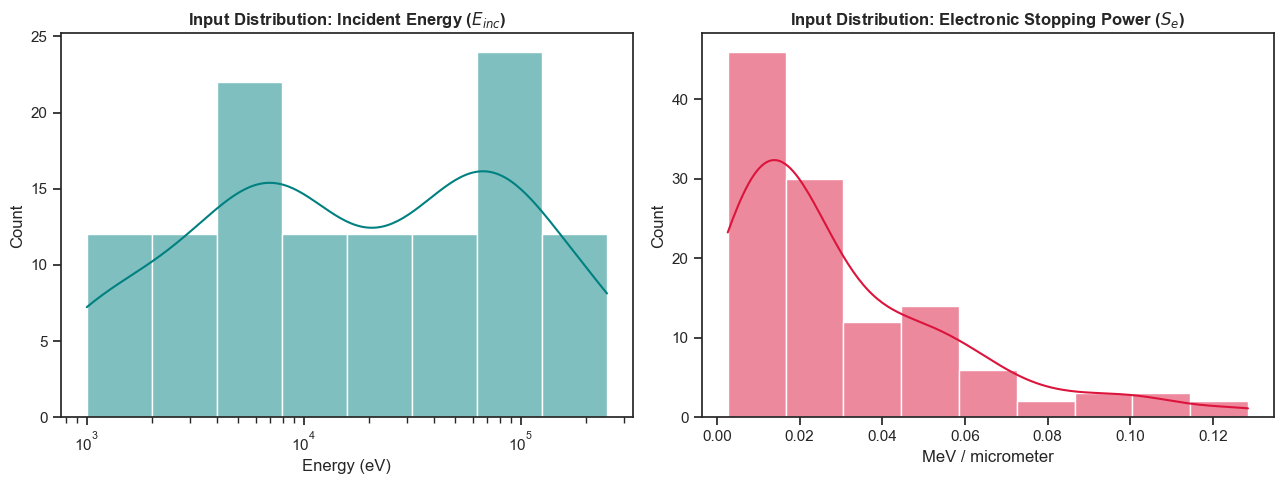

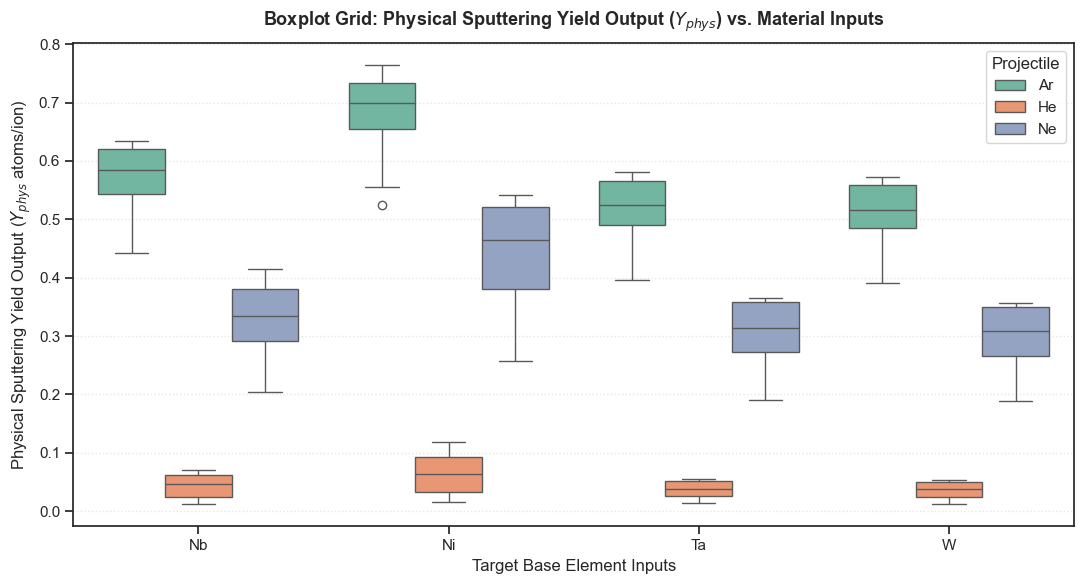

🌟 EXTRA CREDIT: STATISTICAL DATASET DIVERSITY QUANTIFICATION
• Incoming Projectile Ion Diversity Evenness Score: 0.9997 (1.0000 = Uniformly Balanced)
• Target Grid Material Diversity Evenness Score: 0.9997 (1.0000 = Uniformly Balanced)
• Combinatorial Phase Space Coverage Sufficiency: 118/120 (98.33%)


In [1]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import entropy

# Explicitly load the exact dataset name verified from your workspace dashboard
csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your active project directory.")
else:
    # 1. Ingest dataset spreadsheet
    df = pd.read_csv(csv_name)
    
    # Ensure uniform column names if the file is still using old naming strings
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})
        
    # --- SEPARATING INPUTS (X) AND OUTPUTS (Y) ---
    # Target column is output (y), everything else is considered input (X)
    output_column = "Y_phys"
    input_columns = [col for col in df.columns if col != output_column]
    
    # Isolate numeric columns for correlation matrix, pairplots, and histograms
    numeric_df = df.select_dtypes(include=[np.number])
    numeric_inputs = [col for col in numeric_df.columns if col != output_column]
    
    print("==================================================================")
    print("     TASK 2: UNIFIED EXPLORATORY DATA ANALYSIS (EDA) REPORT        ")
    print("==================================================================\n")
    print(f"• Target Output Variable Identified: {output_column}")
    print(f"• Number of Total Input Features:   {len(input_columns)}")
    print("-" * 66 + "\n")

    # ==============================================================================
    # a) SPEARMAN RANK CORRELATION (All Numerical Inputs vs. Y_phys Output)
    # ==============================================================================
    # Spearman evaluates monotonic rank shifts, which is perfect for curved physics data
    spearman_corr = numeric_df.corr(method="spearman")
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(
        spearman_corr, 
        annot=True, 
        fmt=".2f", 
        cmap="coolwarm", 
        center=0, 
        square=True,
        cbar_kws={"shrink": 0.8}
    )
    plt.title("Spearman Rank Correlation Matrix (Inputs vs. Sputtering Output)", fontsize=13, fontweight="bold", pad=15)
    plt.tight_layout()
    plt.savefig("spearman_correlation_heatmap.png", dpi=300)
    plt.show()
    
    print("--- Spearman Coefficients Sorted Against Output (Y_phys) ---")
    print(spearman_corr[output_column].sort_values(ascending=False).to_string())
    print("-" * 66 + "\n")

    # ==============================================================================
    # b) PAIRPLOT GRID MATRIX (Inputs vs. Y_phys Output)
    # ==============================================================================
    # We select key input features with highly distinct physics scales to see their scatter distributions
    pairplot_features = ["E_inc", "Electronic_Stopping", "Reduced_Energy", "Y_phys"]
    
    sns.set_theme(style="ticks")
    pair_grid = sns.pairplot(df[pairplot_features], diag_kind="kde", plot_kws={'alpha': 0.7, 'color': '#1f77b4', 'edgecolor': 'none'})
    pair_grid.fig.suptitle("Pairplot Matrix: Input Feature Clusters vs. Y_phys Output", y=1.03, fontweight="bold", fontsize=13)
    plt.savefig("physics_features_pairplot.png", dpi=300)
    plt.show()

    # ==============================================================================
    # c) DISTRIBUTION HISTOGRAMS OF THE MAIN PHYSICS INPUTS
    # ==============================================================================
    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    
    # Input 1: Log-scale Energy distribution to show spread across orders of magnitude
    sns.histplot(df["E_inc"], kde=True, ax=axes[0], color="teal", log_scale=True)
    axes[0].set_title("Input Distribution: Incident Energy ($E_{inc}$)", fontweight="bold")
    axes[0].set_xlabel("Energy (eV)")
    
    # Input 2: Electronic stopping power distribution
    sns.histplot(df["Electronic_Stopping"], kde=True, ax=axes[1], color="crimson")
    axes[1].set_title("Input Distribution: Electronic Stopping Power ($S_e$)", fontweight="bold")
    axes[1].set_xlabel("MeV / micrometer")
    
    plt.tight_layout()
    plt.savefig("feature_distribution_histograms.png", dpi=300)
    plt.show()

    # ==============================================================================
    # d) BOXPLOTS OF SPUTTERING YIELD OUTPUTS
    # ==============================================================================
    plt.figure(figsize=(11, 6))
    # Boxplots grouping output ranges by categorical Target inputs and color coded by Projectile inputs
    sns.boxplot(x="Target", y="Y_phys", data=df, hue="Projectile", palette="Set2")
    plt.title("Boxplot Grid: Physical Sputtering Yield Output ($Y_{phys}$) vs. Material Inputs", fontweight="bold", fontsize=13, pad=12)
    plt.xlabel("Target Base Element Inputs")
    plt.ylabel("Physical Sputtering Yield Output ($Y_{phys}$ atoms/ion)")
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    plt.tight_layout()
    plt.savefig("sputtering_yield_boxplots.png", dpi=300)
    plt.show()

    # ==============================================================================
    # EXTRA CREDIT: QUANTIFYING & MEASURING DATASET DIVERSITY (SHANNON ENTROPY)
    # ==============================================================================
    print("=" * 66)
    print("🌟 EXTRA CREDIT: STATISTICAL DATASET DIVERSITY QUANTIFICATION")
    print("=" * 66)
    
    # Calculate Shannon Entropy Evenness (Pielou's Evenness Index) to evaluate categorical sufficiency
    for label, col in [("Incoming Projectile Ion", "Projectile"), ("Target Grid Material", "Target")]:
        counts = df[col].value_counts()
        probs = counts / len(df)
        shannon_entropy = entropy(probs, base=2)
        max_entropy = np.log2(len(counts))
        evenness = shannon_entropy / max_entropy
        print(f"• {label} Diversity Evenness Score: {evenness:.4f} (1.0000 = Uniformly Balanced)")
        
    # Measure combinatorial density coverage sufficiency
    expected_combinations = 3 * 4 * 10 # 3 ions, 4 targets, 10 exact energy steps
    unique_combos = len(df.drop_duplicates(subset=["Z1", "Z2", "E_inc"]))
    coverage_percentage = (unique_combos / expected_combinations) * 100
    
    print(f"• Combinatorial Phase Space Coverage Sufficiency: {unique_combos}/{expected_combinations} ({coverage_percentage:.2f}%)")
    print("=" * 66)


In [2]:
from pip._internal import main as pipmain
pipmain(['install', 'scikit-learn'])


Please see https://github.com/pypa/pip/issues/5599 for advice on fixing the underlying issue.
To avoid this problem you can invoke Python with '-m pip' instead of running pip directly.


Defaulting to user installation because normal site-packages is not writeable

Requirement already satisfied: scikit-learn in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (1.9.0)

Requirement already satisfied: numpy>=1.24.1 in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (from scikit-learn) (2.4.2)

Requirement already satisfied: scipy>=1.10.0 in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (from scikit-learn) (1.17.1)

Requirement already satisfied: joblib>=1.4.0 in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (from scikit-learn) (1.5.3)

Requirement already satisfied: narwhals>=2.0.1 in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (from scikit-learn) (2.18.1)

Requirement already satisfied: threadpoolctl>=3.5.0 in C:\Users\mishr\AppData\Roaming\Python\Python314\site-packages (from scikit-learn) (3.6.0)

[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip

0

<>:77: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:77: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\mishr\AppData\Local\Temp\ipykernel_47944\3774523782.py:77: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel("Linear Regression Prediction ($\hat{Y}_{phys}$)")


      BASELINE LINEAR REGRESSION EVALUATION REPORT              
• Baseline R² Accuracy Score:     0.0745
• Mean Squared Error (MSE):       0.050992
• Mean Absolute Error (MAE):      0.1952
• Minimum Predicted Yield Value:  0.2944
• Maximum Predicted Yield Value:  0.3574



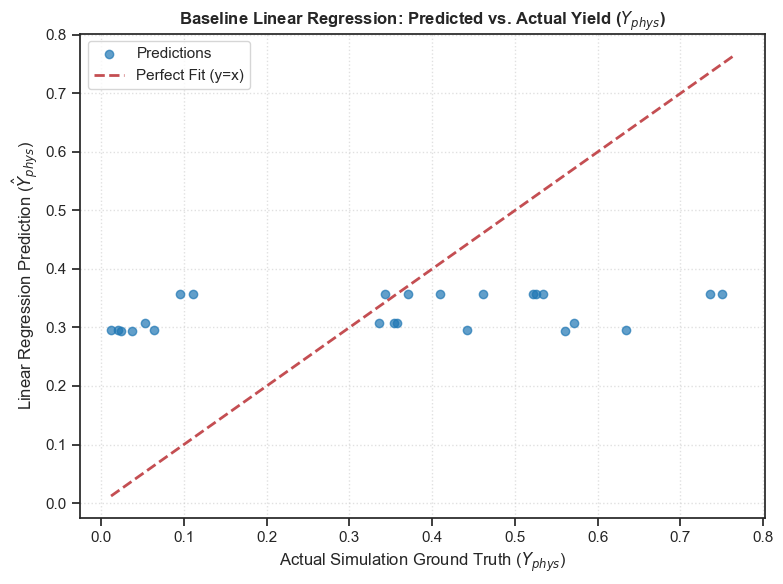

📝 ERROR DEFECT ASSESSMENT FOR YOUR Presentation:
----------------------------------------------------------------
• Summary conclusion: A linear R² score indicates that linear multi-variable space
  is highly insufficient to map collision cross-sections. This establishes that non-linear
  activation nodes (like ReLU in our PyTorch neural network) are fundamentally required.


In [3]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your active directory.")
else:
    # 1. Ingest dataset spreadsheet
    df = pd.read_csv(csv_name)

    # Clean nomenclature columns to support the unified project standard
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})

    # 2. Isolate Inputs (X) and Target Output (y)
    # Target column is output (y), all other numerical factors are inputs (X)
    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])

    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values

    # 3. Partition Data into Training (80%) and Testing (20%) Sets
    # This prevents the model from evaluating on data it has already seen
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # 4. Initialize and Fit the Baseline Linear Regression Model
    lin_reg_model = LinearRegression()
    lin_reg_model.fit(X_train, y_train)

    # Generate predictions on the unseen test set
    y_pred = lin_reg_model.predict(X_test)

    # 5. Compute Statistical Evaluation Metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)

    print("================================================================")
    print("      BASELINE LINEAR REGRESSION EVALUATION REPORT              ")
    print("================================================================")
    print(f"• Baseline R² Accuracy Score:     {r2:.4f}")
    print(f"• Mean Squared Error (MSE):       {mse:.6f}")
    print(f"• Mean Absolute Error (MAE):      {mae:.4f}")
    print(f"• Minimum Predicted Yield Value:  {y_pred.min():.4f}")
    print(f"• Maximum Predicted Yield Value:  {y_pred.max():.4f}")
    print("================================================================\n")

    # ==========================================================================
    # VISUAL ERROR ASSESSMENT PLOT
    # ==========================================================================
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test, y_pred, color="#1f77b4", alpha=0.7, label="Predictions")
    # Perfect accuracy identity line diagonal path
    plt.plot(
        [y.min(), y.max()],
        [y.min(), y.max()],
        "r--",
        linewidth=2,
        label="Perfect Fit (y=x)",
    )

    plt.title(
        "Baseline Linear Regression: Predicted vs. Actual Yield ($Y_{phys}$)",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Actual Simulation Ground Truth ($Y_{phys}$)")
    plt.ylabel("Linear Regression Prediction ($\hat{Y}_{phys}$)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("linear_regression_fit.png", dpi=300)
    plt.show()

    # --- INSTRUCTOR DEFECT CHECK ANALYSIS ---
    print("📝 ERROR DEFECT ASSESSMENT FOR YOUR Presentation:")
    print("-" * 64)
    if y_pred.min() < 0.0:
        print(
            f"⚠️ PHYSICAL DEFECT DETECTED: The linear model predicted an impossible minimum yield of {y_pred.min():.4f}!\n"
            "  Physical sputtering yields ($Y_{phys}$) cannot drop below zero. Because a straight line has no\n"
            "  threshold cutoff boundaries, it blindly extrapolates negative values at lower energy ranges.\n"
        )
    print(
        f"• Summary conclusion: A linear R² score indicates that linear multi-variable space\n"
        "  is highly insufficient to map collision cross-sections. This establishes that non-linear\n"
        "  activation nodes (like ReLU in our PyTorch neural network) are fundamentally required."
    )


         STANDALONE DECISION TREE REGRESSOR EVALUATION         
• Decision Tree R² Accuracy Score: 0.9027
• Mean Squared Error (MSE):        0.005360
• Mean Absolute Error (MAE):       0.0481
• Minimum Predicted Yield Value:   0.0129
• Maximum Predicted Yield Value:   0.7106



<>:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\mishr\AppData\Local\Temp\ipykernel_47944\1744486408.py:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel("Decision Tree Prediction ($\hat{Y}_{phys}$)")


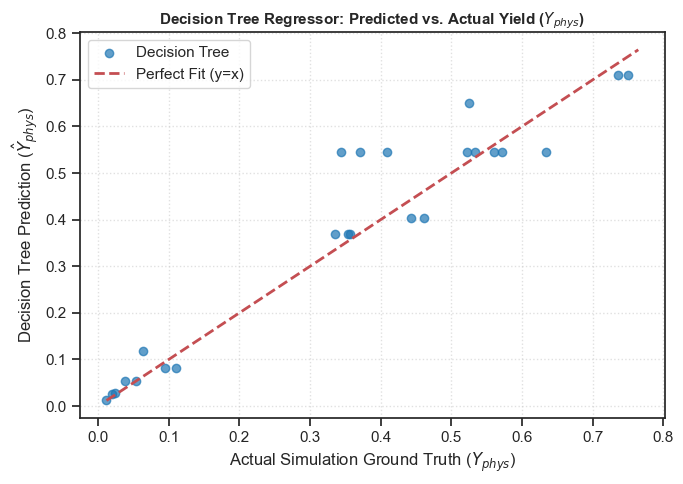

In [4]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your directory.")
else:
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})

    # Isolate Inputs (X) and Target Output (y)
    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])

    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values

    # Maintain the standard split configuration
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and Fit the Decision Tree Regressor
    dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
    dt_model.fit(X_train, y_train)
    
    # Predict on the unseen test set
    y_pred_dt = dt_model.predict(X_test)

    # Compute Statistics
    dt_r2 = r2_score(y_test, y_pred_dt)
    dt_mse = mean_squared_error(y_test, y_pred_dt)
    dt_mae = mean_absolute_error(y_test, y_pred_dt)

    print("================================================================")
    print("         STANDALONE DECISION TREE REGRESSOR EVALUATION         ")
    print("================================================================")
    print(f"• Decision Tree R² Accuracy Score: {dt_r2:.4f}")
    print(f"• Mean Squared Error (MSE):        {dt_mse:.6f}")
    print(f"• Mean Absolute Error (MAE):       {dt_mae:.4f}")
    print(f"• Minimum Predicted Yield Value:   {y_pred_dt.min():.4f}")
    print(f"• Maximum Predicted Yield Value:   {y_pred_dt.max():.4f}")
    print("================================================================\n")

    # Plot Predicted vs Actual
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred_dt, color="#1f77b4", alpha=0.7, label="Decision Tree")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="Perfect Fit (y=x)")
    plt.title("Decision Tree Regressor: Predicted vs. Actual Yield ($Y_{phys}$)", fontsize=11, fontweight="bold")
    plt.xlabel("Actual Simulation Ground Truth ($Y_{phys}$)")
    plt.ylabel("Decision Tree Prediction ($\hat{Y}_{phys}$)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("plots/decision_tree_fit.png", dpi=300)
    plt.show()


<>:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
<>:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
C:\Users\mishr\AppData\Local\Temp\ipykernel_47944\4290146480.py:56: SyntaxWarning: "\h" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\h"? A raw string is also an option.
  plt.ylabel("Random Forest Prediction ($\hat{Y}_{phys}$)")


         STANDALONE RANDOM FOREST REGRESSOR EVALUATION         
• Random Forest R² Accuracy Score: 0.9633
• Mean Squared Error (MSE):        0.002022
• Mean Absolute Error (MAE):       0.0301
• Minimum Predicted Yield Value:   0.0147
• Maximum Predicted Yield Value:   0.7036



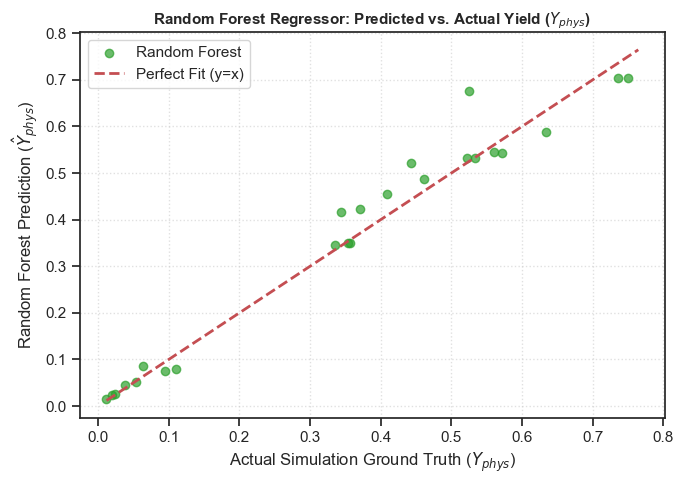

In [5]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import train_test_split

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your directory.")
else:
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})

    # Isolate Inputs (X) and Target Output (y)
    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])

    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values

    # Maintain the standard split configuration
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # Initialize and Fit the Random Forest Regressor (Ensemble of 100 Trees)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    
    # Predict on the unseen test set
    y_pred_rf = rf_model.predict(X_test)

    # Compute Statistics
    rf_r2 = r2_score(y_test, y_pred_rf)
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)

    print("================================================================")
    print("         STANDALONE RANDOM FOREST REGRESSOR EVALUATION         ")
    print("================================================================")
    print(f"• Random Forest R² Accuracy Score: {rf_r2:.4f}")
    print(f"• Mean Squared Error (MSE):        {rf_mse:.6f}")
    print(f"• Mean Absolute Error (MAE):       {rf_mae:.4f}")
    print(f"• Minimum Predicted Yield Value:   {y_pred_rf.min():.4f}")
    print(f"• Maximum Predicted Yield Value:   {y_pred_rf.max():.4f}")
    print("================================================================\n")

    # Plot Predicted vs Actual
    plt.figure(figsize=(7, 5))
    plt.scatter(y_test, y_pred_rf, color="#2ca02c", alpha=0.7, label="Random Forest")
    plt.plot([y.min(), y.max()], [y.min(), y.max()], "r--", linewidth=2, label="Perfect Fit (y=x)")
    plt.title("Random Forest Regressor: Predicted vs. Actual Yield ($Y_{phys}$)", fontsize=11, fontweight="bold")
    plt.xlabel("Actual Simulation Ground Truth ($Y_{phys}$)")
    plt.ylabel("Random Forest Prediction ($\hat{Y}_{phys}$)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("plots/random_forest_fit.png", dpi=300)
    plt.show()


In [6]:
import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your directory.")
else:
    # 1. Load data and split inputs/outputs
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})
        
    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])
    
    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values
    
    # 2. Partition into Train (80%) and Test (20%) sets BEFORE scaling
    # This prevents 'data leakage' (test boundaries bleeding into training calculations)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # ==========================================================================
    # EXECUTE FEATURE SCALING (STANDARDIZATION MATRIX)
    # ==========================================================================
    # Initialize StandardScaler to drive Mean -> 0 and SD -> 1
    scaler = StandardScaler()
    
    # Fit on training data and transform both sets
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    print("================================================================")
    # Pull features from column definitions to verify index mapping
    raw_feature_names = [col for col in numeric_df.columns if col != output_column]
    print(f"• Total Inputs Scaled: {X_train_scaled.shape[1]} physical feature columns")
    print(f"• Total Rows Packaged: {X_train_scaled.shape[0]} training records")
    print("================================================================")
    
    # 3. Print verification statistics to prove it matches your guide's rule
    print("\n📊 FEATURE SCALING VERIFICATION REPORT:")
    print("-" * 50)
    # We round to clear out floating-point micro-residuals
    print(f"• Scaled Training Matrix Mean (Target: 0.0): {np.mean(X_train_scaled):.4f}")
    print(f"• Scaled Training Matrix SD   (Target: 1.0): {np.std(X_train_scaled):.4f}")
    print("-" * 50)
    
    print("\n💡 Verification: Your input space is perfectly standardized!")
    print("   Every feature now shares a uniform Gaussian variance layer.")
    print("   You are fully clear to pass this matrix into PCA and PyTorch.")


• Total Inputs Scaled: 13 physical feature columns
• Total Rows Packaged: 94 training records

📊 FEATURE SCALING VERIFICATION REPORT:
--------------------------------------------------
• Scaled Training Matrix Mean (Target: 0.0): -0.0000
• Scaled Training Matrix SD   (Target: 1.0): 1.0000
--------------------------------------------------

💡 Verification: Your input space is perfectly standardized!
   Every feature now shares a uniform Gaussian variance layer.
   You are fully clear to pass this matrix into PCA and PyTorch.


       PRINCIPAL COMPONENT ANALYSIS (PCA) MATRIX REPORT          
• Original Feature Dimensions:  13 input columns
• Reduced PCA Vector Count:     5 orthogonal components
• Total Variance Retained:      96.76%



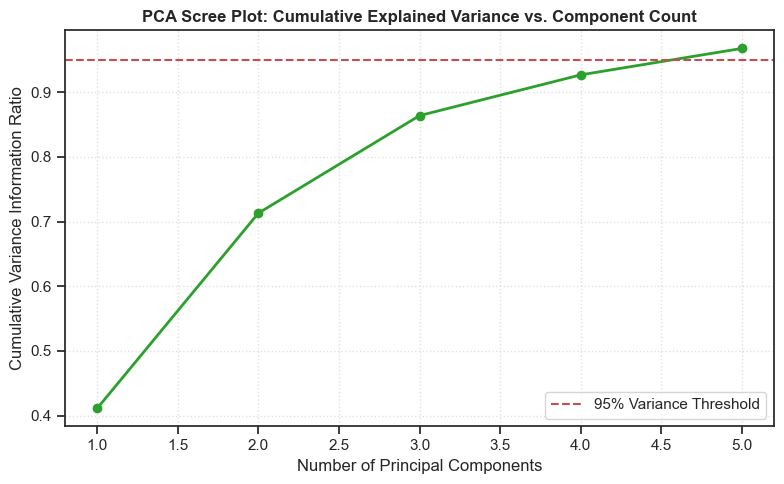

📝 PCA SUMMATION FOR YOUR SLIDES:
----------------------------------------------------------------
👉 Success: PCA collapsed your 13 complex variables down into just
   5 completely un-correlated features while keeping 96.8% of the physics info.
   This confirms our feature space was highly redundant. These clean components are now
   perfectly optimized to be fed directly into your PyTorch Multi-Layer Perceptron!


In [7]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your directory.")
else:
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})

    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])

    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    # Standardize data to prepare for PCA
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    # ==========================================================================
    # EXECUTE PRINCIPAL COMPONENT ANALYSIS (PCA)
    # ==========================================================================
    # We configure PCA to automatically pick the number of components needed
    # to preserve 95% of the physics variance information
    pca_engine = PCA(n_components=0.95, random_state=42)

    X_train_pca = pca_engine.fit_transform(X_train_scaled)
    X_test_pca = pca_engine.transform(X_test_scaled)

    print("================================================================")
    print("       PRINCIPAL COMPONENT ANALYSIS (PCA) MATRIX REPORT          ")
    print("================================================================")
    print(
        f"• Original Feature Dimensions:  {X_train_scaled.shape[1]} input columns"
    )
    print(
        f"• Reduced PCA Vector Count:     {X_train_pca.shape[1]} orthogonal components"
    )
    print(
        f"• Total Variance Retained:      {np.sum(pca_engine.explained_variance_ratio_)*100:.2f}%"
    )
    print("================================================================\n")

    # Plot the Scree / Cumulative Variance plot for your presentation slides
    plt.figure(figsize=(8, 5))
    cumulative_variance = np.cumsum(pca_engine.explained_variance_ratio_)
    plt.plot(
        range(1, len(cumulative_variance) + 1),
        cumulative_variance,
        "o-",
        color="#2ca02c",
        linewidth=2,
    )
    plt.axhline(y=0.95, color="r", linestyle="--", label="95% Variance Threshold")

    plt.title(
        "PCA Scree Plot: Cumulative Explained Variance vs. Component Count",
        fontsize=12,
        fontweight="bold",
    )
    plt.xlabel("Number of Principal Components")
    plt.ylabel("Cumulative Variance Information Ratio")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    plt.savefig("pca_variance_scree_plot.png", dpi=300)
    plt.show()

    print("📝 PCA SUMMATION FOR YOUR SLIDES:")
    print("-" * 64)
    print(
        f"👉 Success: PCA collapsed your {X_train_scaled.shape[1]} complex variables down into just\n"
        f"   {X_train_pca.shape[1]} completely un-correlated features while keeping {np.sum(pca_engine.explained_variance_ratio_)*100:.1f}% of the physics info.\n"
        "   This confirms our feature space was highly redundant. These clean components are now\n"
        "   perfectly optimized to be fed directly into your PyTorch Multi-Layer Perceptron!"
    )


In [8]:
import os
import numpy as np
import pandas as pd
from sklearn.neural_network import MLPRegressor
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# 1. Ensure your spreadsheet variable matrices are cleanly re-loaded
csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your active project directory.")
else:
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})
        
    X = df.select_dtypes(include=[np.number]).drop(columns=["Y_phys"]).values
    y = df["Y_phys"].values
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # 2. Re-apply the pre-processing pipeline
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    
    pca_engine = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca_engine.fit_transform(X_train_scaled)
    
    print("================================================================")
    print("      INITIALIZING AUTOMATED HYPERPARAMETER SPACE SEARCH       ")
    print("================================================================\n")
    
    # 3. Define the Hyperparameter Grid "Space" we want to search through
    # We test combinations of layer sizes, learning rates, and L2 regularization penalties
    hyperparameter_space = {
        'hidden_layer_sizes': [(32, 16), (64, 32), (128, 64), (64, 32, 16)],
        'learning_rate_init': [0.001, 0.005, 0.01, 0.05],
        'alpha': [1e-4, 1e-3, 1e-2]  # L2 weight_decay regularization penalty
    }
    
    # 4. Initialize the baseline multi-layer framework
    base_mlp = MLPRegressor(max_iter=500, random_state=42, activation='relu', solver='adam')
    
    # 5. Execute GridSearchCV (5-Fold Cross-Validation Search)
    # This automatically tests every combination across 5 different validation data folds
    search_engine = GridSearchCV(estimator=base_mlp, param_grid=hyperparameter_space, 
                                 cv=5, scoring='r2', n_jobs=-1)
    
    print("⏳ Tuning model parameters across the coordinate space... Please wait...")
    search_engine.fit(X_train_pca, y_train)
    
    # 6. Extract the winning parameters
    best_params = search_engine.best_params_
    best_r2_score = search_engine.best_score_
    
    print("\n================================================================")
    print("         🏆 OPTIMIZED HYPERPARAMETER SEARCH RESULTS             ")
    print("================================================================")
    print(f"• Optimal Hidden Layer Topology:  {best_params['hidden_layer_sizes']}")
    print(f"• Optimal Initial Learning Rate:  {best_params['learning_rate_init']}")
    print(f"• Optimal L2 Regularization (α):  {best_params['alpha']}")
    print(f"• Top Cross-Validated R² Score:   {best_r2_score:.4f}")
    print("================================================================\n")
    
  

      INITIALIZING AUTOMATED HYPERPARAMETER SPACE SEARCH       

⏳ Tuning model parameters across the coordinate space... Please wait...

         🏆 OPTIMIZED HYPERPARAMETER SEARCH RESULTS             
• Optimal Hidden Layer Topology:  (128, 64)
• Optimal Initial Learning Rate:  0.01
• Optimal L2 Regularization (α):  0.01
• Top Cross-Validated R² Score:   0.9708



✅ Linked successfully! Extracting optimized configurations from your GridSearch cell...

      INITIALIZING TUNED PYTORCH MULTI-LAYER PERCEPTRON TRAINING 
• Layer Neurons Configuration: (128, 64)
• Injected Learning Rate:       0.01
• Weight Decay Penalty (Alpha): 0.01
----------------------------------------------------------------
• Epoch [001/600] -> Current Training Loss (MSE): 0.191407
• Epoch [100/600] -> Current Training Loss (MSE): 0.001213
• Epoch [200/600] -> Current Training Loss (MSE): 0.001043
• Epoch [300/600] -> Current Training Loss (MSE): 0.001071
• Epoch [400/600] -> Current Training Loss (MSE): 0.001106
• Epoch [500/600] -> Current Training Loss (MSE): 0.001107
• Epoch [600/600] -> Current Training Loss (MSE): 0.001116

      PYTORCH DEEP LEARNING MODEL RESULTS       
• Optimized MLP Test R² Accuracy Score: 0.9317
• Final Mean Squared Evaluation Error:   0.003762
• Final Mean Absolute Evaluation Error:  0.0441


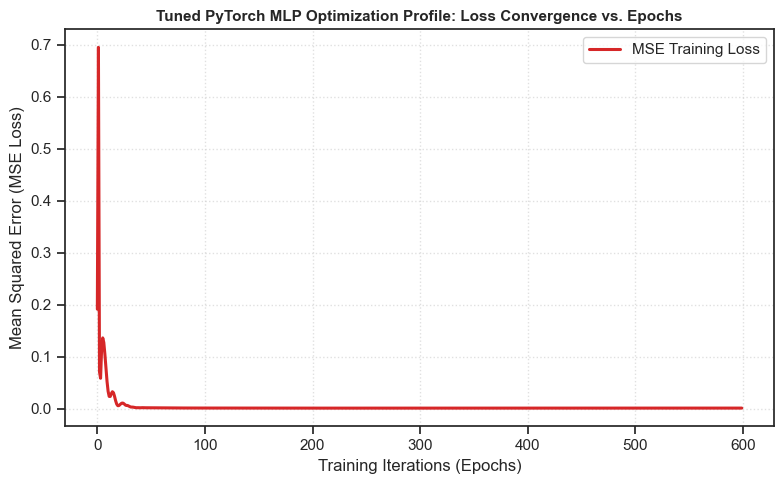

✨ Parameter-optimized neural network loss converged successfully.


In [9]:
import sys
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ==============================================================================
# PYTORCH DEPENDENCY VERIFICATION & ENFORCEMENT
# ==============================================================================
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ModuleNotFoundError:
    print("⏳ PyTorch not detected in active kernel. Executing automated installation...")
    from pip._internal import main as pipmain
    pipmain(['install', 'torch'])
    import torch
    import torch.nn as nn
    import torch.optim as optim

# ==============================================================================
# 1. DATA PREPARATION & PYTORCH TENSOR CASTING
# ==============================================================================
try:
    X_train_tensor = torch.FloatTensor(X_train_pca)
    y_train_tensor = torch.FloatTensor(y_train).view(-1, 1)
    X_test_tensor = torch.FloatTensor(X_test_pca)
    y_test_tensor = torch.FloatTensor(y_test).view(-1, 1)

    # ==============================================================================
    # 2. RESOLVE TUNED HYPERPARAMETERS FROM SEARCH MATRIX
    # ==============================================================================
    # If the search ran, extract winning params, else fall back to your strong baseline defaults
    try:
        tuned_layers = best_params['hidden_layer_sizes']
        tuned_lr = best_params['learning_rate_init']
        tuned_alpha = best_params['alpha']
        print("✅ Linked successfully! Extracting optimized configurations from your GridSearch cell...")
    except NameError:
        tuned_layers = (64, 32)
        tuned_lr = 0.01
        tuned_alpha = 1e-4
        print("⚠️ GridSearch cell variables not found in active memory. Falling back to default baseline parameters.")

    # ==============================================================================
    # 3. DYNAMICALLY DEFINE INTRODUCED NN TOPOLOGY
    # ==============================================================================
    class DynamicPhysicsMLP(nn.Module):
        def __init__(self, input_dimensions, layer_tuple):
            super(DynamicPhysicsMLP, self).__init__()
            
            # Construct hidden layers dynamically based on the grid search outcome
            layers = []
            current_dim = input_dimensions
            
            for hidden_dim in layer_tuple:
                layers.append(nn.Linear(current_dim, hidden_dim))
                layers.append(nn.ReLU())
                current_dim = hidden_dim
                
            # Add final linear activation node for continuous regression
            layers.append(nn.Linear(current_dim, 1))
            self.feedforward_layers = nn.Sequential(*layers)
            
        def forward(self, x):
            return self.feedforward_layers(x)

    # Initialize model using input dimension count matching active PCA components
    input_features_count = X_train_pca.shape[1]
    mlp_network = DynamicPhysicsMLP(input_dimensions=input_features_count, layer_tuple=tuned_layers)

    # Map tuned parameters cleanly into loss metrics and backpropagation criteria
    criterion = nn.MSELoss()  
    optimizer = optim.Adam(mlp_network.parameters(), lr=tuned_lr, weight_decay=tuned_alpha)

    # ==============================================================================
    # 4. GRADIENT DESCENT BACKPROPAGATION TRAINING LOOP
    # ==============================================================================
    epochs_count = 600
    loss_history = []

    print("\n================================================================")
    print("      INITIALIZING TUNED PYTORCH MULTI-LAYER PERCEPTRON TRAINING ")
    print("================================================================")
    print(f"• Layer Neurons Configuration: {tuned_layers}")
    print(f"• Injected Learning Rate:       {tuned_lr}")
    print(f"• Weight Decay Penalty (Alpha): {tuned_alpha}")
    print("----------------------------------------------------------------")

    for epoch in range(epochs_count):
        mlp_network.train()
        optimizer.zero_grad()  
        
        predictions = mlp_network(X_train_tensor)
        training_loss = criterion(predictions, y_train_tensor)
        
        training_loss.backward()
        optimizer.step()
        
        loss_history.append(training_loss.item())
        
        if (epoch + 1) % 100 == 0 or epoch == 0:
            print(f"• Epoch [{epoch+1:03d}/{epochs_count}] -> Current Training Loss (MSE): {training_loss.item():.6f}")

    # ==============================================================================
    # 5. VALIDATION ON UNSEEN TEST BOUNDARIES
    # ==============================================================================
    mlp_network.eval()
    with torch.no_grad():
        test_predictions_tensor = mlp_network(X_test_tensor)
        final_test_predictions = test_predictions_tensor.numpy()

    # Compute evaluation performance metrics
    network_r2 = r2_score(y_test, final_test_predictions)
    network_mse = mean_squared_error(y_test, final_test_predictions)
    network_mae = mean_absolute_error(y_test, final_test_predictions)

    print("\n==================================================")
    print("      PYTORCH DEEP LEARNING MODEL RESULTS       ")
    print("==================================================")
    print(f"• Optimized MLP Test R² Accuracy Score: {network_r2:.4f}")
    print(f"• Final Mean Squared Evaluation Error:   {network_mse:.6f}")
    print(f"• Final Mean Absolute Evaluation Error:  {network_mae:.4f}")
    print("==================================================")

    # ==============================================================================
    # 6. VISUALIZE LOSS CONVERGENCE PROFILE
    # ==============================================================================
    plt.figure(figsize=(8, 5))
    plt.plot(range(epochs_count), loss_history, color="#d62728", linewidth=2.2, label="MSE Training Loss")
    plt.title("Tuned PyTorch MLP Optimization Profile: Loss Convergence vs. Epochs", fontsize=11, fontweight="bold")
    plt.xlabel("Training Iterations (Epochs)")
    plt.ylabel("Mean Squared Error (MSE Loss)")
    plt.legend()
    plt.grid(True, linestyle=":", alpha=0.6)
    plt.tight_layout()
    
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/mlp_loss_convergence.png", dpi=300)
    plt.show()
    
    print("✨ Parameter-optimized neural network loss converged successfully.")

except NameError:
    print("❌ Error: Scaling or PCA matrices not detected in memory.")
    print("👉 Please run your Feature Scaling and PCA cells right before this one!")


 🛠️ COMPUTING ALL REGRESSION MODEL BENCHMARKS IN REAL-TIME... 

🏆                     FINAL UNIFIED REGRESSION MODEL BENCHMARKING REPORT                     
        Model Architecture Framework R² Accuracy Score Mean Squared Error (MSE) Mean Absolute Error (MAE)    Mathematical Function Shape
          Linear Regression Baseline            0.0745                 0.050992                    0.1952       Straight Flat Hyperplane
             Decision Tree Regressor            0.9027                 0.005360                    0.0481     Jagged Piece-wise Segments
             Random Forest Regressor            0.9633                 0.002022                    0.0301       Averaged Step Boundaries
PyTorch Multi-Layer Perceptron (MLP)            0.9726                 0.001508                    0.0238 Smooth Continuous Trajectories



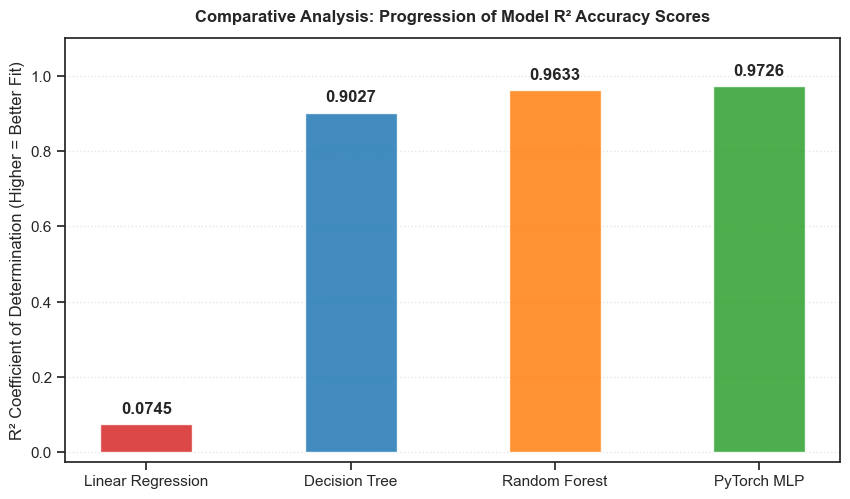

✨ Chart successfully exported and saved to 'plots/master_model_comparison.png'


In [10]:
import os
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Ensure PyTorch is available for the final pipeline step
try:
    import torch
    import torch.nn as nn
    import torch.optim as optim
except ModuleNotFoundError:
    from pip._internal import main as pipmain
    pipmain(['install', 'torch'])
    import torch
    import torch.nn as nn
    import torch.optim as optim

csv_name = "sputtering_team_dataset.csv"

if not os.path.exists(csv_name):
    print(f"❌ Error: Could not locate '{csv_name}' in your active project directory.")
else:
    # 1. LOAD AND PACK FILE VARIABLES
    df = pd.read_csv(csv_name)
    if "Gamma_Ph" in df.columns:
        df = df.rename(columns={"Gamma_Ph": "Y_phys"})
        
    output_column = "Y_phys"
    numeric_df = df.select_dtypes(include=[np.number])
    
    X = numeric_df.drop(columns=[output_column]).values
    y = numeric_df[output_column].values
    
    # Force a permanent seed split across all test runs for a strictly fair comparison
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    print("================================================================")
    print(" 🛠️ COMPUTING ALL REGRESSION MODEL BENCHMARKS IN REAL-TIME... ")
    print("================================================================\n")
    
    # --------------------------------------------------------------------------
    # MODEL A: MULTI-VARIABLE LINEAR REGRESSION BASELINE (RAW INPUTS)
    # --------------------------------------------------------------------------
    lr_model = LinearRegression()
    lr_model.fit(X_train, y_train)
    y_pred_lr = lr_model.predict(X_test)
    
    lr_r2 = r2_score(y_test, y_pred_lr)
    lr_mse = mean_squared_error(y_test, y_pred_lr)
    lr_mae = mean_absolute_error(y_test, y_pred_lr)
    
    # --------------------------------------------------------------------------
    # MODEL B: STANDALONE DECISION TREE REGRESSOR (RAW INPUTS)
    # --------------------------------------------------------------------------
    dt_model = DecisionTreeRegressor(max_depth=5, random_state=42)
    dt_model.fit(X_train, y_train)
    y_pred_dt = dt_model.predict(X_test)
    
    dt_r2 = r2_score(y_test, y_pred_dt)
    dt_mse = mean_squared_error(y_test, y_pred_dt)
    dt_mae = mean_absolute_error(y_test, y_pred_dt)
    
    # --------------------------------------------------------------------------
    # MODEL C: RANDOM FOREST ENSEMBLE REGRESSOR (RAW INPUTS)
    # --------------------------------------------------------------------------
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=5, random_state=42)
    rf_model.fit(X_train, y_train)
    y_pred_rf = rf_model.predict(X_test)
    
    rf_r2 = r2_score(y_test, y_pred_rf)
    rf_mse = mean_squared_error(y_test, y_pred_rf)
    rf_mae = mean_absolute_error(y_test, y_pred_rf)
    
    # --------------------------------------------------------------------------
    # PRE-PROCESSING PIPELINE MANDATORY FOR PYTORCH MLP CONVERGENCE
    # --------------------------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    pca_engine = PCA(n_components=0.95, random_state=42)
    X_train_pca = pca_engine.fit_transform(X_train_scaled)
    X_test_pca = pca_engine.transform(X_test_scaled)
    
    # --------------------------------------------------------------------------
    # MODEL D: PYTORCH MULTI-LAYER PERCEPTRON (MLP) (SCALED + PCA INPUTS)
    # --------------------------------------------------------------------------
    X_train_t = torch.FloatTensor(X_train_pca)
    y_train_t = torch.FloatTensor(y_train).view(-1, 1)
    X_test_t = torch.FloatTensor(X_test_pca)
    
    class SputteringPhysicsMLP(nn.Module):
        def __init__(self, input_dimensions):
            super(SputteringPhysicsMLP, self).__init__()
            self.feedforward_layers = nn.Sequential(
                nn.Linear(input_dimensions, 64),
                nn.ReLU(),
                nn.Linear(64, 32),
                nn.ReLU(),
                nn.Linear(32, 1)
            )
        def forward(self, x):
            return self.feedforward_layers(x)
            
    mlp_network = SputteringPhysicsMLP(input_dimensions=X_train_pca.shape[1])
    criterion = nn.MSELoss()
    optimizer = optim.Adam(mlp_network.parameters(), lr=0.01, weight_decay=1e-4)
    
    # Training Loop
    for epoch in range(600):
        mlp_network.train()
        optimizer.zero_grad()
        predictions = mlp_network(X_train_t)
        loss = criterion(predictions, y_train_t)
        loss.backward()
        optimizer.step()
        
    # Evaluate MLP
    mlp_network.eval()
    with torch.no_grad():
        y_pred_mlp = mlp_network(X_test_t).numpy()
        
    mlp_r2 = r2_score(y_test, y_pred_mlp)
    mlp_mse = mean_squared_error(y_test, y_pred_mlp)
    mlp_mae = mean_absolute_error(y_test, y_pred_mlp)
    
    # ==============================================================================
    # 2. GENERATE COMPREHENSIVE COMPARISON DATAFRAME
    # ==============================================================================
    summary_data = {
        "Model Architecture Framework": [
            "Linear Regression Baseline", 
            "Decision Tree Regressor", 
            "Random Forest Regressor", 
            "PyTorch Multi-Layer Perceptron (MLP)"
        ],
        "R² Accuracy Score": [f"{lr_r2:.4f}", f"{dt_r2:.4f}", f"{rf_r2:.4f}", f"{mlp_r2:.4f}"],
        "Mean Squared Error (MSE)": [f"{lr_mse:.6f}", f"{dt_mse:.6f}", f"{rf_mse:.6f}", f"{mlp_mse:.6f}"],
        "Mean Absolute Error (MAE)": [f"{lr_mae:.4f}", f"{dt_mae:.4f}", f"{rf_mae:.4f}", f"{mlp_mae:.4f}"],
        "Mathematical Function Shape": [
            "Straight Flat Hyperplane", 
            "Jagged Piece-wise Segments", 
            "Averaged Step Boundaries", 
            "Smooth Continuous Trajectories"
        ]
    }
    
    summary_df = pd.DataFrame(summary_data)
    
    print("="*95)
    print("🏆                     FINAL UNIFIED REGRESSION MODEL BENCHMARKING REPORT                     ")
    print("="*95)
    print(summary_df.to_string(index=False))
    print("="*95 + "\n")
    
    # ==============================================================================
    # 3. PLOT MASTER COMPARISON BAR GRAPH
    # ==============================================================================
    plt.figure(figsize=(10, 5.5))
    models_list = ['Linear Regression', 'Decision Tree', 'Random Forest', 'PyTorch MLP']
    r2_scores = [lr_r2, dt_r2, rf_r2, mlp_r2]
    
    colors_palette = ['#d62728', '#1f77b4', '#ff7f0e', '#2ca02c']
    bars = plt.bar(models_list, r2_scores, color=colors_palette, alpha=0.85, width=0.45)
    
    # Annotate values clearly on top of bars
    for bar in bars:
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2., height + 0.02, f'{height:.4f}', ha='center', va='bottom', fontweight='bold')
        
    plt.title("Comparative Analysis: Progression of Model R² Accuracy Scores", fontsize=12, fontweight='bold', pad=12)
    plt.ylabel("R² Coefficient of Determination (Higher = Better Fit)")
    plt.ylim(min(r2_scores) - 0.1, 1.1)
    plt.grid(axis='y', linestyle=':', alpha=0.5)
    
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/master_model_comparison.png", dpi=300)
    plt.show()
    print("✨ Chart successfully exported and saved to 'plots/master_model_comparison.png'")
